In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\subha\OneDrive\Desktop\Programming\python\dataAnalytics\Finlatics\ML_Research\Facebook Dataset\Facebook_Marketplace_data.csv")
df.set_index('status_id', inplace = True)
df.columns

Index(['status_type', 'status_published', 'num_reactions', 'num_comments',
       'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas',
       'num_sads', 'num_angrys', 'Column1', 'Column2', 'Column3', 'Column4'],
      dtype='object')

In [4]:
df['status_published'] = pd.to_datetime(df['status_published'],format='%m/%d/%Y %H:%M')

In [5]:
df = df.dropna(axis= 'columns', how = 'all')

In [6]:
df.head()

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
status_id,,,,,,,,,,,
1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0
2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0
3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0
4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0
5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0


In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [62]:
DF = df[['status_type','num_reactions','num_comments','num_shares','num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']].copy()

In [63]:
DF.loc[DF['status_type']=='photo'] = 0
DF.loc[DF['status_type']=='video'] = 1
DF.loc[DF['status_type']=='status'] = 2
DF.loc[DF['status_type']=='link'] = 3

In [64]:
DF['status_type'] = (DF['status_type']).astype(int)

In [65]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7050 entries, 1 to 7050
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    7050 non-null   int64
 1   num_reactions  7050 non-null   int64
 2   num_comments   7050 non-null   int64
 3   num_shares     7050 non-null   int64
 4   num_likes      7050 non-null   int64
 5   num_loves      7050 non-null   int64
 6   num_wows       7050 non-null   int64
 7   num_hahas      7050 non-null   int64
 8   num_sads       7050 non-null   int64
 9   num_angrys     7050 non-null   int64
dtypes: int64(10)
memory usage: 605.9 KB


In [66]:
le = LabelEncoder()

DF['status_type'] = le.fit_transform(DF['status_type'])

In [69]:
scaler = StandardScaler()
DF_scaled = scaler.fit_transform(DF)

In [70]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(DF_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\subha\miniconda3\Lib\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\subha\miniconda3\Lib\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\subha\miniconda3\Lib\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\subha\miniconda3\Lib\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\subha\miniconda3\Lib\site-packa

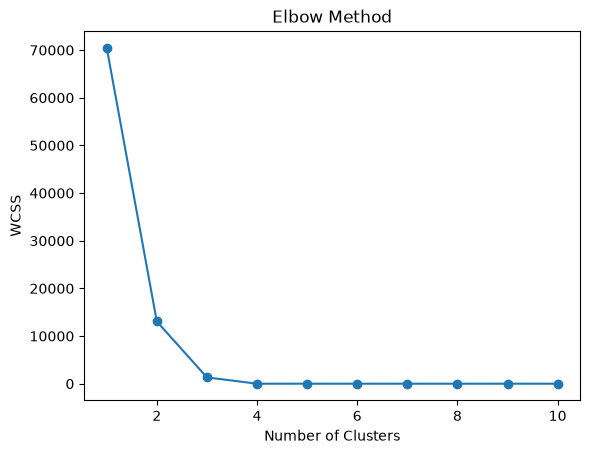

In [72]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [78]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(DF_scaled)

In [83]:
DF['Cluster'] = clusters

In [85]:
DF['Cluster'].value_counts()

Cluster
0    4288
1    2334
2     428
Name: count, dtype: int64

In [81]:
DF.groupby('Cluster')[['num_reactions','num_comments','num_shares']].mean()

,num_reactions,num_comments,num_shares
Cluster,,,
0,0.000000,0.000000,0.000000
1,1.000000,1.000000,1.000000
2,2.147196,2.147196,2.147196


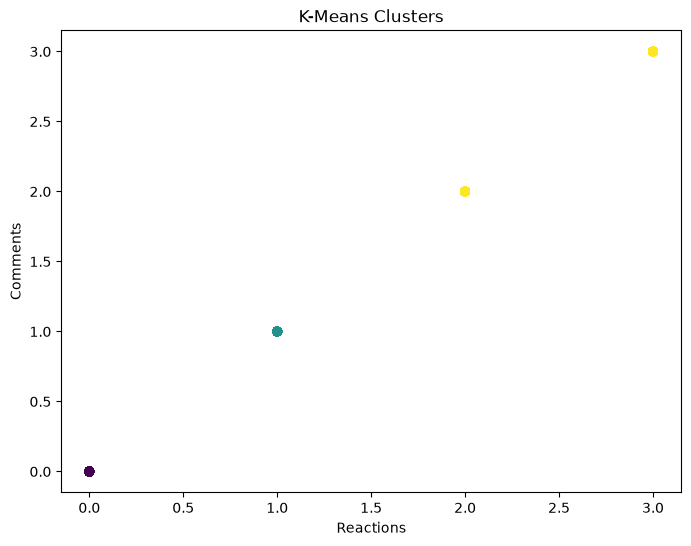

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(DF['num_reactions'],DF['num_comments'],c=DF['Cluster'])

plt.xlabel('Reactions')
plt.ylabel('Comments')
plt.title('K-Means Clusters')
plt.show()

In [1]:
del DF

NameError: name 'DF' is not defined